# Análise de Outliers e Volatilidade (Eventos Extremos)

O objetivo desta análise é identificar **outliers** (retornos diários excepcionalmente altos ou baixos) nas ações que compõem o IBOVESPA. 

Em modelos de **Index Tracking**, ativos que sofrem grande volatilidade ou crises isoladas podem introduzir *Tracking Errors* severos no portfólio de replicação. Diferente de abordagens anteriores, utilizamos aqui os **retornos simples (percentuais)** para garantir que o limite de corte reflita as quedas reais do mercado (como os *Circuit Breakers* da B3).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import os

# Caminho dinâmico (funciona tanto se abrir da raiz quanto da pasta data)
caminho_retornos = 'ibov_retornos_simples.csv' if os.path.exists('ibov_retornos_simples.csv') else 'data/ibov_retornos_simples.csv'

# Lendo o CSV de retornos SIMPLES
outlier_retorno = pd.read_csv(caminho_retornos)

# Convertendo a coluna 'Date' para o formato de calendário
outlier_retorno['Date'] = pd.to_datetime(outlier_retorno['Date'])

# Mostrando as 3 primeiras linhas para confirmar que deu certo
display(outlier_retorno.head(3))


,Date,ABEV3.SA,AXIA3.SA,AXIA6.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC3.SA,BBDC4.SA,BBSE3.SA,...,TAEE11.SA,TIMS3.SA,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VBBR3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA
0,2018-01-03,0.002305,-0.012773,-0.016026,0.030195,0.017023,0.012754,0.004254,0.004598,0.000697,...,0.001398,0.000757,0.021227,-0.009874,0.033333,-0.005992,0.0,-0.028985,-0.015188,0.000886
1,2018-01-04,-0.005520,-0.006469,0.014425,0.031552,0.006438,0.009595,0.018209,0.016407,0.002089,...,-0.015822,-0.004542,-0.006171,0.011678,0.056452,0.004099,0.0,0.010945,-0.009740,-0.004130
2,2018-01-05,0.003700,-0.009224,-0.025229,-0.033595,0.014499,0.000000,0.000304,0.005665,0.006602,...,0.004728,0.008365,0.021569,0.002075,-0.042939,0.015610,0.0,0.002461,0.004099,-0.013626


In [2]:
# 1. Pegamos o nome de todas as colunas de ações, ignorando a coluna de Data
ticker_columns = [col for col in outlier_retorno.columns if col != 'Date']

# 2. Transformamos a tabela larga em uma tabela super comprida de 3 colunas
df_melted = outlier_retorno.melt(
    id_vars=['Date'],            # A coluna 'Date' fica paradinha como âncora
    value_vars=ticker_columns,   # As colunas das ações vão ser empilhadas
    var_name='Ticker',           # Nomeamos a nova coluna de ações de 'Ticker'
    value_name='Retorno'         # Nomeamos a coluna dos valores percentuais de 'Retorno'
)

# Comparando o tamanho do antes e depois
print(f"Formato da tabela original: {outlier_retorno.shape}")
print(f"Formato da tabela derretida: {df_melted.shape}")
display(df_melted.head())


Formato da tabela original: (1818, 63)
Formato da tabela derretida: (112716, 3)


,Date,Ticker,Retorno
0,2018-01-03,ABEV3.SA,0.002305
1,2018-01-04,ABEV3.SA,-0.005520
2,2018-01-05,ABEV3.SA,0.003700
3,2018-01-08,ABEV3.SA,-0.001843
4,2018-01-09,ABEV3.SA,-0.002770


## 1. Mapeamento de Eventos Extremos (> 15%)

Para analisar todo o mercado simultaneamente, aplicamos a técnica de "derretimento" (`melt`) no dataframe. Isso nos permite enfileirar todos os retornos diários de todas as 79 ações. Em seguida, filtramos eventos onde o retorno absoluto foi superior a **15%** no dia.


In [3]:
# Definindo o nosso limite do sarrafo (15%)
limite_outlier = 0.15

# 1. Filtramos as linhas onde o Retorno absoluto (positivo ou negativo) é maior que 0.15
retornos_extremos = df_melted[df_melted['Retorno'].abs() > limite_outlier].copy()

# 2. Vamos ordenar para que as maiores quedas/altas do século apareçam no topo da lista
retornos_extremos = retornos_extremos.sort_values(by='Retorno', key=abs, ascending=False)

print(f"Total de eventos extremos encontrados na nossa base: {len(retornos_extremos)}")
display(retornos_extremos.head(15).style.format({'Retorno': '{:.2%}'}))



Total de eventos extremos encontrados na nossa base: 214


,Date,Ticker,Retorno
100850,2021-06-28 00:00:00,UGPA3.SA,119.33%
56589,2018-12-07 00:00:00,ISAE4.SA,44.89%
78712,2020-03-09 00:00:00,PRIO3.SA,-36.54%
54006,2023-03-09 00:00:00,HAPV3.SA,-33.56%
54000,2023-03-01 00:00:00,HAPV3.SA,-32.74%
78715,2020-03-12 00:00:00,PRIO3.SA,-32.69%
78724,2020-03-25 00:00:00,PRIO3.SA,32.29%
22366,2020-03-25 00:00:00,BRKM5.SA,31.75%
78888,2020-11-19 00:00:00,PRIO3.SA,29.94%
75076,2020-03-09 00:00:00,PETR4.SA,-29.70%


In [7]:
import os

# 1. Contando as ações mais problemáticas (quem apareceu mais na nossa lista)
contagem_acoes = retornos_extremos['Ticker'].value_counts()
print("As 5 ações com mais retornos extremos na década:")
display(contagem_acoes.head(5))

# Pegamos as 3 primeiras colocadas automaticamente para o nosso gráfico
acoes_alvo = contagem_acoes.head(15).index.tolist()
print(f"\nAções que vamos comparar com o IBOVESPA: {acoes_alvo}\n")

# 2. Carregando os dados do Índice IBOVESPA
caminho_indice = 'ibov_indice.csv' if os.path.exists('ibov_indice.csv') else 'data/ibov_indice.csv'
indice_ibov = pd.read_csv(caminho_indice)

# Convertendo data e calculando a variação do IBOVESPA
indice_ibov['Date'] = pd.to_datetime(indice_ibov['Date'])
# Calcula os retornos percentuais diários para o indice e multiplica por 100 para o IBOV também ficar em porcentagem (igual as ações)
indice_ibov['Retorno_IBOV'] = indice_ibov['^BVSP'].pct_change() * 100 

print("Tabela do IBOVESPA carregada e pronta para o gráfico:")
display(indice_ibov[['Date', '^BVSP', 'Retorno_IBOV']].head())


As 5 ações com mais retornos extremos na década:


Ticker
PRIO3.SA     12
BRKM5.SA     12
MGLU3.SA     11
HAPV3.SA      9
BPAC11.SA     8
Name: count, dtype: int64


Ações que vamos comparar com o IBOVESPA: ['PRIO3.SA', 'BRKM5.SA', 'MGLU3.SA', 'HAPV3.SA', 'BPAC11.SA', 'MBRF3.SA', 'COGN3.SA', 'UGPA3.SA', 'PETR3.SA', 'AXIA3.SA', 'CSNA3.SA', 'YDUQ3.SA', 'USIM5.SA', 'AXIA6.SA', 'PETR4.SA']

Tabela do IBOVESPA carregada e pronta para o gráfico:


,Date,^BVSP,Retorno_IBOV
0,2018-01-02,77891.0,NaN
1,2018-01-03,77995.0,0.133520
2,2018-01-04,78647.0,0.835951
3,2018-01-05,79071.0,0.539118
4,2018-01-08,79379.0,0.389523


## 2. Comportamento das Ações Mais Voláteis vs IBOVESPA (Crise Covid-19)

Ao mapearmos a frequência de retornos extremos, isolamos as ações mais instáveis da década. Nesta etapa, cruzamos o comportamento das Top ações mais problemáticas contra a linha base do IBOVESPA durante a eclosão da pandemia de COVID-19 (Fev a Jun/2020). 

Isso evidencia como ativos altamente elásticos puxam o índice em momentos de *Crash* sistêmico.


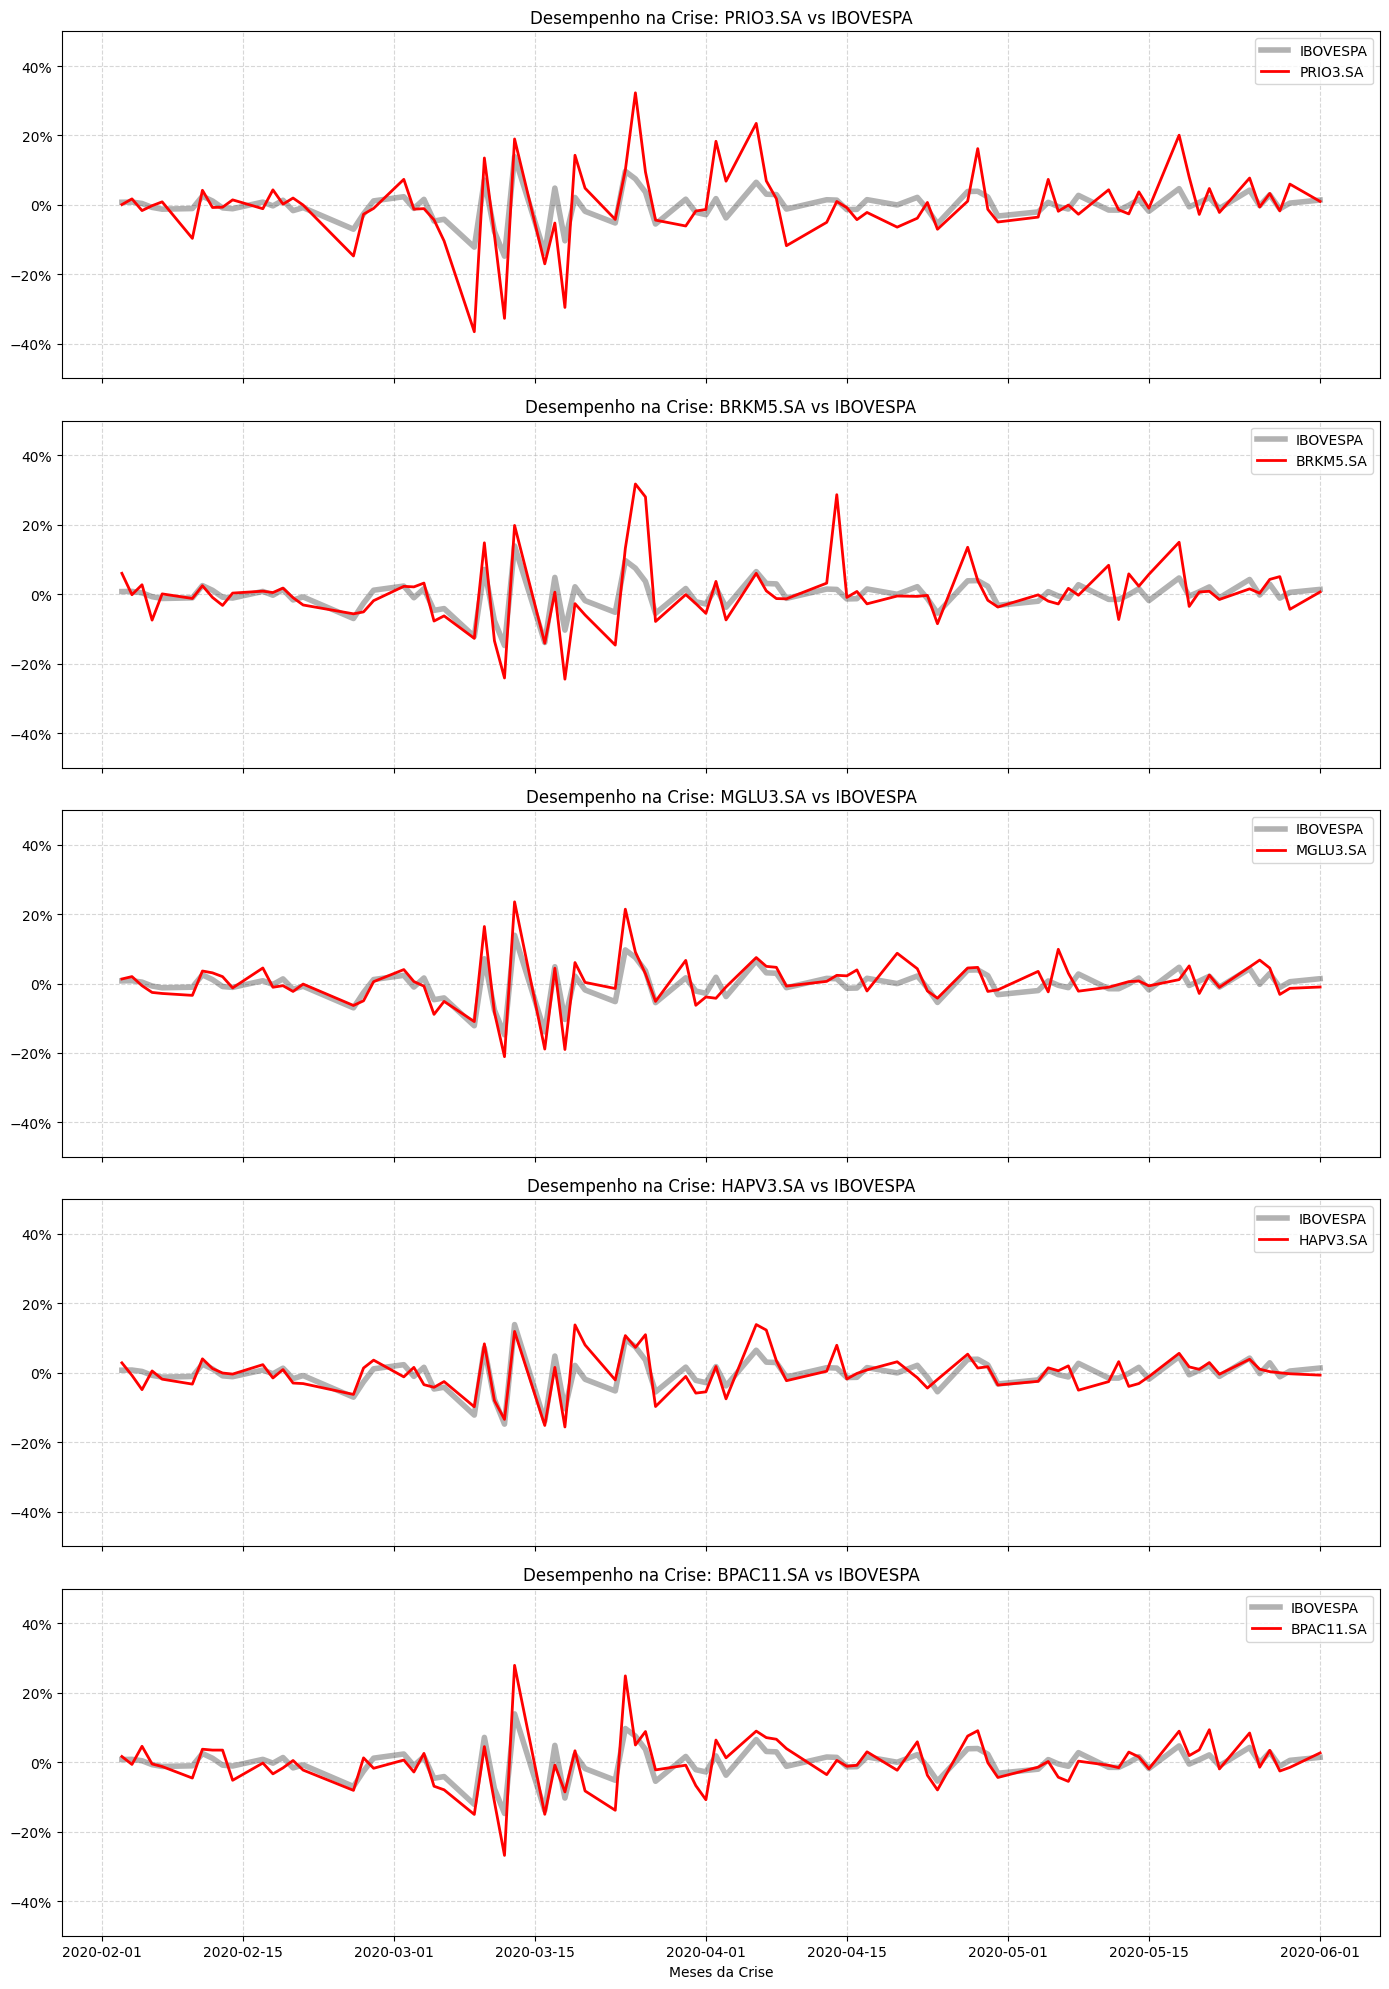

In [5]:
# Definindo o período da maior crise (Covid-19)
inicio = '2020-02-01'
fim = '2020-06-01'

# Recortando a tabela do IBOVESPA só para esse período
ibov_2020 = indice_ibov[(indice_ibov['Date'] >= inicio) & (indice_ibov['Date'] <= fim)]

# Contamos quantas ações existem na lista (agora são 5)
qtd_graficos = len(acoes_alvo)

# Criamos a tela dinamicamente (qtd de linhas = qtd de ações). A altura da imagem também cresce junto!
fig, axs = plt.subplots(qtd_graficos, 1, figsize=(14, 4 * qtd_graficos), sharex=True)

# Um laço de repetição que vai desenhar cada gráfico
for i, ticker in enumerate(acoes_alvo):
    
    # Pega apenas os dados daquela ação específica no período da crise
    acao_dados = df_melted[(df_melted['Ticker'] == ticker) & 
                           (df_melted['Date'] >= inicio) & 
                           (df_melted['Date'] <= fim)]
    
    # Desenha a linha de sombra do IBOVESPA (em cinza grosso)
    axs[i].plot(ibov_2020['Date'], ibov_2020['Retorno_IBOV'], label='IBOVESPA', color='black', linewidth=4, alpha=0.3)
    
    # Desenha a linha da Ação (multiplicada por 100 para comparar igual)
    axs[i].plot(acao_dados['Date'], acao_dados['Retorno'] * 100, label=ticker, color='red', linewidth=2)
    
    # Perfumaria: Títulos, formato de porcentagem e limite da régua
    axs[i].set_title(f'Desempenho na Crise: {ticker} vs IBOVESPA')
    axs[i].legend()
    axs[i].yaxis.set_major_formatter(mtick.PercentFormatter(100.0)) 
    axs[i].set_ylim(-50, 50) 
    axs[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Meses da Crise')
plt.tight_layout()
plt.show()


## 3. Risco Sistêmico vs Risco Idiossincrático

Nem toda crise afeta a bolsa inteira. Na literatura financeira, é vital separar:
* **Risco Sistêmico:** Colapsos que afetam todas as empresas simultaneamente (ex: Pandemia em Mar/2020).
* **Risco Idiossincrático:** Crises isoladas que afetam apenas uma empresa ou setor (ex: Rompimento de barragens, fraudes contábeis, intervenções estatais).

O gráfico de dispersão abaixo plota todos os eventos extremos no tempo, permitindo identificar visualmente os blocos de queda sistêmica (paredes verticais) e os pontos de queda isolada de ativos específicos.


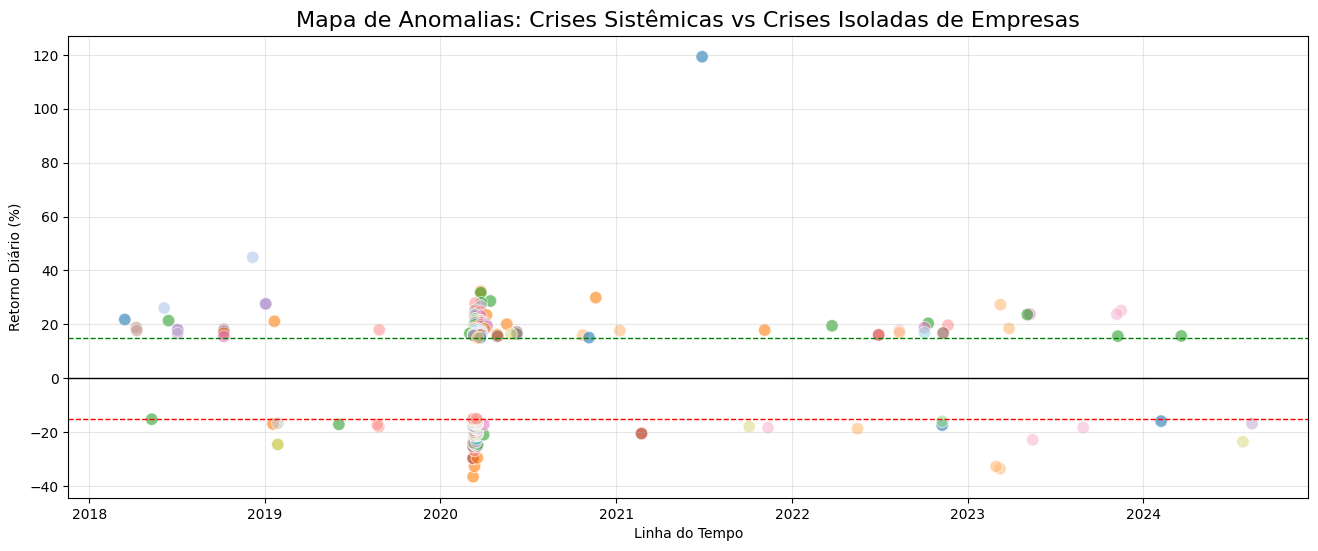

In [6]:
import seaborn as sns

plt.figure(figsize=(16, 6))

# Desenhamos um gráfico de pontos com todos os eventos extremos de 2018 até hoje
sns.scatterplot(
    data=retornos_extremos, 
    x='Date', 
    y=retornos_extremos['Retorno'] * 100, 
    hue='Ticker', # Cores diferentes para cada ação
    palette='tab20',
    s=80, # Tamanho da bolinha
    alpha=0.6,
    legend=False # Desligamos a legenda senão ficariam 79 nomes na tela
)

# Adicionamos linhas de referência
plt.axhline(0, color='black', linewidth=1)
plt.axhline(-15, color='red', linewidth=1, linestyle='--', label='Sarrafo de -15%')
plt.axhline(15, color='green', linewidth=1, linestyle='--', label='Sarrafo de +15%')

plt.title('Mapa de Anomalias: Crises Sistêmicas vs Crises Isoladas de Empresas', fontsize=16)
plt.ylabel('Retorno Diário (%)')
plt.xlabel('Linha do Tempo')
plt.grid(True, alpha=0.3)
plt.show()
